# Dự Báo Nhu Cầu Sản Phẩm

Notebook này thực hiện dự báo nhu cầu sản phẩm dựa trên dữ liệu doanh số từ tầng gold của lakehouse. Chúng ta sẽ sử dụng dữ liệu từ bảng `fact_sales` và các bảng chiều như `dim_product` và `dim_date` để xây dựng mô hình dự báo thời gian.

**Mục tiêu:**
- Tải và tiền xử lý dữ liệu doanh số.
- Áp dụng mô hình dự báo thời gian (ví dụ: Prophet).
- Đánh giá kết quả và lưu mô hình.

In [1]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession

# Khởi tạo Spark Session
spark = SparkSession.builder \
    .appName("Demand Forecasting") \
    .config("spark.sql.iceberg.vectorization.enabled", "false") \
    .getOrCreate()

In [ ]:
# Tải dữ liệu từ bảng fact_sales
fact_sales_df = spark.read.table("lakehouse.gold.fact_sales")
fact_sales_pd = fact_sales_df.toPandas()

# Tải dữ liệu từ bảng dim_date
dim_date_df = spark.read.table("lakehouse.gold.dim_date")
dim_date_pd = dim_date_df.toPandas()

# Tải dữ liệu từ bảng dim_product
dim_product_df = spark.read.table("lakehouse.gold.dim_product")
dim_product_pd = dim_product_df.toPandas()


In [ ]:
# Chuyển đổi dữ liệu để dự báo
# Kết hợp fact_sales với dim_date để có thông tin ngày đầy đủ
sales_date = fact_sales_pd.merge(dim_date_pd, left_on='order_date_key', right_on='date_key')

# Nhóm dữ liệu theo ngày và sản phẩm để tính tổng số lượng bán
daily_sales = sales_date.groupby(['date', 'product_sk']).agg({'quantity': 'sum'}).reset_index()

# Kết hợp với dim_product để có thông tin sản phẩm
daily_sales_product = daily_sales.merge(dim_product_pd, on='product_sk')


In [23]:
# Chuẩn bị dữ liệu cho mô hình Prophet
# Lấy dữ liệu của một sản phẩm cụ thể để thử nghiệm
product_id = daily_sales_product['product_sk'].iloc[7]
product_data = daily_sales_product[daily_sales_product['product_sk'] == product_id]

# Định dạng dữ liệu cho Prophet (cần cột 'ds' cho ngày và 'y' cho giá trị)
prophet_data = product_data[['date', 'quantity']].rename(columns={'date': 'ds', 'quantity': 'y'})

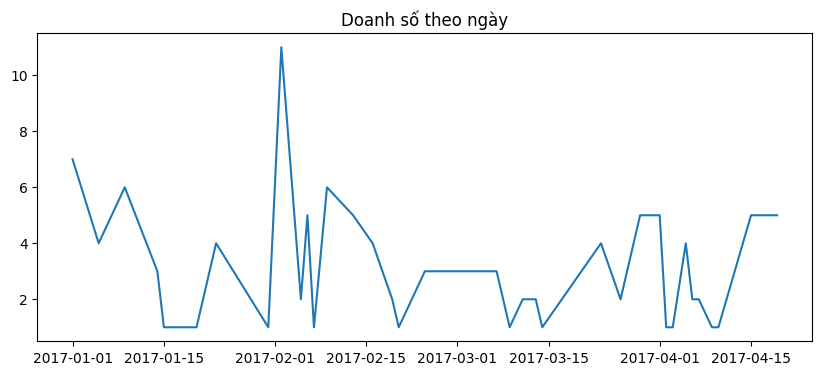

In [24]:
plt.figure(figsize=(10,4))
plt.plot(prophet_data['ds'], prophet_data['y'])
plt.title("Doanh số theo ngày")
plt.show()


01:01:53 - cmdstanpy - INFO - Chain [1] start processing
01:01:53 - cmdstanpy - INFO - Chain [1] done processing


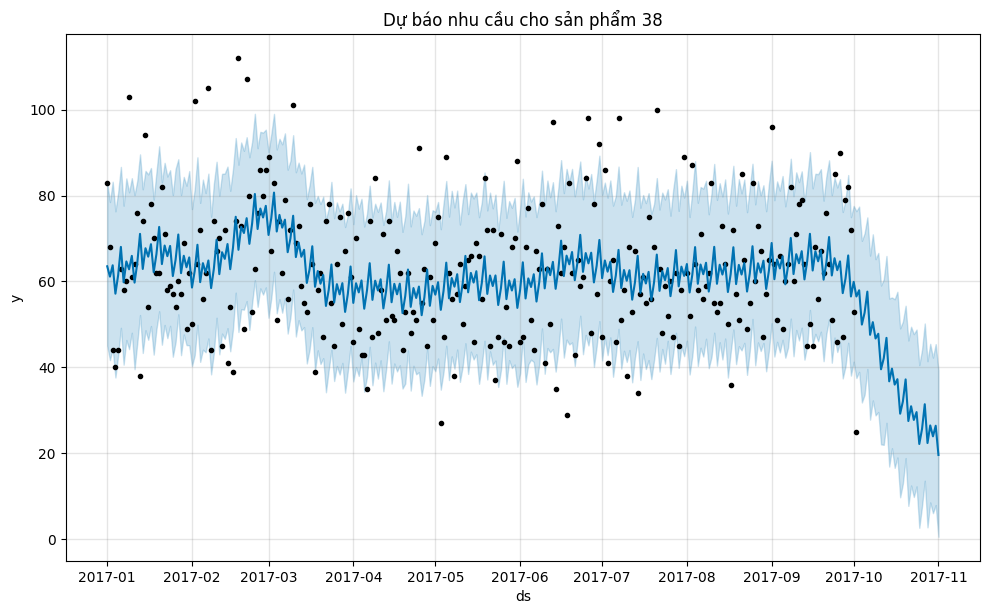

In [16]:
# Chuẩn bị dữ liệu cho mô hình Prophet
# Lấy dữ liệu của một sản phẩm cụ thể để thử nghiệm
product_id = daily_sales_product['product_sk'].iloc[4]
product_data = daily_sales_product[daily_sales_product['product_sk'] == product_id]

# Định dạng dữ liệu cho Prophet (cần cột 'ds' cho ngày và 'y' cho giá trị)
prophet_data = product_data[['date', 'quantity']].rename(columns={'date': 'ds', 'quantity': 'y'})

# Khởi tạo và huấn luyện mô hình Prophet
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(prophet_data)

# Tạo dataframe cho dự báo trong tương lai
future_dates = model.make_future_dataframe(periods=30)

# Dự báo
forecast = model.predict(future_dates)

# Vẽ biểu đồ kết quả
fig = model.plot(forecast)
plt.title(f"Dự báo nhu cầu cho sản phẩm {product_id}")
plt.show()

In [ ]:
# Lưu mô hình và kết quả
# (Lưu ý: Prophet không hỗ trợ lưu mô hình trực tiếp, cần lưu kết quả dự báo)
forecast.to_csv("forecast_results.csv", index=False)
print("Kết quả dự báo đã được lưu vào forecast_results.csv")